# 01 — EDA & Preprocessing: Student Success Predictor

**Problem:** Predict whether a university student will Graduate, Dropout, or remain Enrolled using enrollment data and 1st-semester academic performance.

**Notebook objectives:**
- Load and inspect the UCI Student Success dataset (4,424 students, 36 features)
- Perform exploratory data analysis to identify the most predictive signals
- Engineer new features capturing academic trajectory and performance rates
- Produce a stratified 80/20 train/test split and save processed data to `data/processed/`

In [3]:
import sys

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from ucimlrepo import fetch_ucirepo

# Paths
PROJECT_ROOT = Path.cwd().parent  # notebooks/ is one level below root
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
ARTIFACTS = PROJECT_ROOT / "artifacts"

# Style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

print("✅ Imports OK")
print(f"PROJECT_ROOT: {PROJECT_ROOT}")

✅ Imports OK
PROJECT_ROOT: C:\Users\DIEGUINHO\Documents\Especializacion\Curso-1\student-success-predictor


## 1. Data Loading

In [4]:
dataset = fetch_ucirepo(id=697)
X = dataset.data.features
y = dataset.data.targets

df = pd.concat([X, y], axis=1)

print(f"Shape: {df.shape}")
print(f"\nColumns ({len(df.columns)}):")
for col in df.columns:
    print(f"  - {repr(col)}")

Shape: (4424, 37)

Columns (37):
  - 'Marital Status'
  - 'Application mode'
  - 'Application order'
  - 'Course'
  - 'Daytime/evening attendance'
  - 'Previous qualification'
  - 'Previous qualification (grade)'
  - 'Nacionality'
  - "Mother's qualification"
  - "Father's qualification"
  - "Mother's occupation"
  - "Father's occupation"
  - 'Admission grade'
  - 'Displaced'
  - 'Educational special needs'
  - 'Debtor'
  - 'Tuition fees up to date'
  - 'Gender'
  - 'Scholarship holder'
  - 'Age at enrollment'
  - 'International'
  - 'Curricular units 1st sem (credited)'
  - 'Curricular units 1st sem (enrolled)'
  - 'Curricular units 1st sem (evaluations)'
  - 'Curricular units 1st sem (approved)'
  - 'Curricular units 1st sem (grade)'
  - 'Curricular units 1st sem (without evaluations)'
  - 'Curricular units 2nd sem (credited)'
  - 'Curricular units 2nd sem (enrolled)'
  - 'Curricular units 2nd sem (evaluations)'
  - 'Curricular units 2nd sem (approved)'
  - 'Curricular units 2nd sem 

In [5]:
print("=== DTYPES ===")
print(df.dtypes.value_counts())
print("\n=== MISSING VALUES ===")
print(df.isnull().sum().sum(), "total missing values")
print("\n=== SAMPLE ===")
df.head()

=== DTYPES ===
int64      29
float64     7
str         1
Name: count, dtype: int64

=== MISSING VALUES ===
0 total missing values

=== SAMPLE ===


,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [9]:
display(df.head(10))

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
5,2,39,1,9991,0,19,133.1,1,37,37,...,0,5,17,5,11.500000,5,16.2,0.3,-0.92,Graduate
6,1,1,1,9500,1,1,142.0,1,19,38,...,0,8,8,8,14.345000,0,15.5,2.8,-4.06,Graduate
7,1,18,4,9254,1,1,119.0,1,37,37,...,0,5,5,0,0.000000,0,15.5,2.8,-4.06,Dropout
8,1,1,3,9238,1,1,137.0,62,1,1,...,0,6,7,6,14.142857,0,16.2,0.3,-0.92,Graduate
9,1,1,1,9238,1,1,138.0,1,1,19,...,0,6,14,2,13.500000,0,8.9,1.4,3.51,Dropout


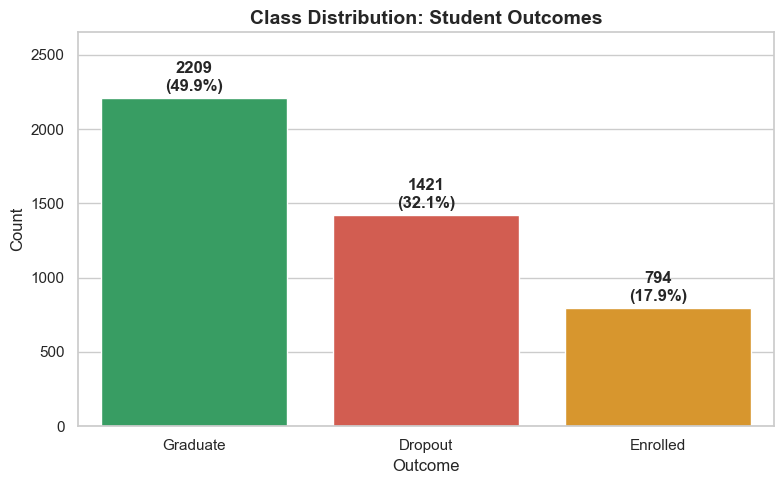


Class distribution:
  Graduate: 2209 (49.9%)
  Dropout: 1421 (32.1%)
  Enrolled: 794 (17.9%)


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

class_counts = df["Target"].value_counts()
class_pcts = df["Target"].value_counts(normalize=True) * 100
palette = {"Dropout": "#e74c3c", "Enrolled": "#f39c12", "Graduate": "#27ae60"}

sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
    palette=[palette.get(c, "#999") for c in class_counts.index],
    ax=ax
)

for i, cls in enumerate(class_counts.index):
    cnt = class_counts[cls]
    pct = class_pcts[cls]
    ax.text(i, cnt + 30, f"{cnt}\n({pct:.1f}%)", ha="center", va="bottom", fontweight="bold")

ax.set_title("Class Distribution: Student Outcomes", fontsize=14, fontweight="bold")
ax.set_xlabel("Outcome")
ax.set_ylabel("Count")
ax.set_ylim(0, class_counts.max() * 1.2)
plt.tight_layout()
plt.show()

print("\nClass distribution:")
for cls in class_counts.index:
    print(f"  {cls}: {class_counts[cls]} ({class_pcts[cls]:.1f}%)")

## 2. Feature Groups

In [7]:
FEATURE_GROUPS = {
    "demographic": [
        "Marital Status", "Gender", "Age at enrollment",
        "Nacionality", "International", "Displaced"
    ],
    "application": [
        "Application mode", "Application order", "Course",
        "Daytime/evening attendance\t",
        "Previous qualification", "Previous qualification (grade)",
        "Admission grade"
    ],
    "family_background": [
        "Mother's qualification", "Father's qualification",
        "Mother's occupation", "Father's occupation"
    ],
    "financial_social": [
        "Tuition fees up to date", "Scholarship holder",
        "Debtor", "Educational special needs"
    ],
    "sem1_academic": [
        "Curricular units 1st sem (credited)",
        "Curricular units 1st sem (enrolled)",
        "Curricular units 1st sem (evaluations)",
        "Curricular units 1st sem (approved)",
        "Curricular units 1st sem (grade)",
        "Curricular units 1st sem (without evaluations)"
    ],
    "sem2_academic": [
        "Curricular units 2nd sem (credited)",
        "Curricular units 2nd sem (enrolled)",
        "Curricular units 2nd sem (evaluations)",
        "Curricular units 2nd sem (approved)",
        "Curricular units 2nd sem (grade)",
        "Curricular units 2nd sem (without evaluations)"
    ],
    "macroeconomic": [
        "Unemployment rate", "Inflation rate", "GDP"
    ]
}

# Validate and auto-fix feature names against actual df.columns
feature_cols = [c for c in df.columns if c != "Target"]
print(f"Actual feature columns ({len(feature_cols)}):")

for group_name, features in FEATURE_GROUPS.items():
    for i, feat in enumerate(features):
        if feat not in feature_cols:
            stripped = feat.strip()
            if stripped in feature_cols:
                FEATURE_GROUPS[group_name][i] = stripped
                print(f"Fixed [{group_name}]: {repr(feat)} -> {repr(stripped)}")
            else:
                print(f"⚠️  UNRESOLVED mismatch [{group_name}]: {repr(feat)}")

grouped_flat = [f for group in FEATURE_GROUPS.values() for f in group]
mismatches = [f for f in grouped_flat if f not in feature_cols]

if mismatches:
    print(f"\n⚠️  Still mismatched ({len(mismatches)}): {mismatches}")
else:
    print("\n✅ All feature names match dataset columns")

print(f"\nFeature group sizes:")
for name, feats in FEATURE_GROUPS.items():
    print(f"  {name}: {len(feats)} features")

print(f"\nFeatures in groups: {len(grouped_flat)}")
print(f"Actual features:    {len(feature_cols)}")

Actual feature columns (36):
Fixed [application]: 'Daytime/evening attendance\t' -> 'Daytime/evening attendance'

✅ All feature names match dataset columns

Feature group sizes:
  demographic: 6 features
  application: 7 features
  family_background: 4 features
  financial_social: 4 features
  sem1_academic: 6 features
  sem2_academic: 6 features
  macroeconomic: 3 features

Features in groups: 36
Actual features:    36


## 3. EDA — Academic Features (Most Predictive)

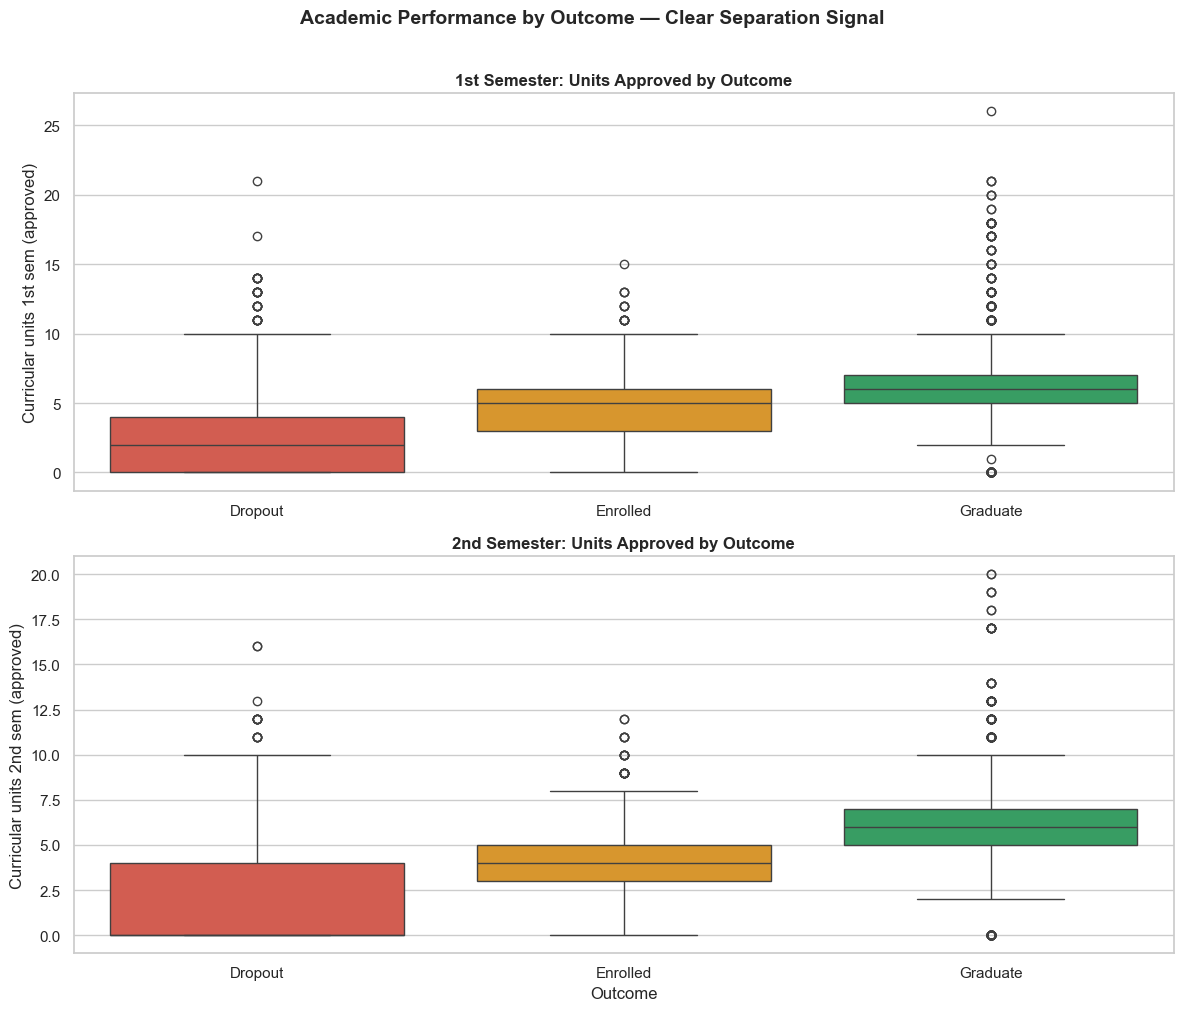

In [12]:
palette = {"Dropout": "#e74c3c", "Enrolled": "#f39c12", "Graduate": "#27ae60"}
order = ["Dropout", "Enrolled", "Graduate"]

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

sns.boxplot(
    data=df, x="Target", y="Curricular units 1st sem (approved)",
    order=order, palette=palette, ax=axes[0]
)
axes[0].set_title("1st Semester: Units Approved by Outcome", fontsize=12, fontweight="bold")
axes[0].set_xlabel("")

sns.boxplot(
    data=df, x="Target", y="Curricular units 2nd sem (approved)",
    order=order, palette=palette, ax=axes[1]
)
axes[1].set_title("2nd Semester: Units Approved by Outcome", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Outcome")

fig.suptitle("Academic Performance by Outcome — Clear Separation Signal", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

sns.boxplot(
    data=df, x="Target", y="Curricular units 1st sem (grade)",
    order=order, palette=palette, ax=axes[0]
)
axes[0].set_title("1st Semester: Grade by Outcome", fontsize=12, fontweight="bold")
axes[0].set_xlabel("")

sns.boxplot(
    data=df, x="Target", y="Curricular units 2nd sem (grade)",
    order=order, palette=palette, ax=axes[1]
)
axes[1].set_title("2nd Semester: Grade by Outcome", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Outcome")

fig.suptitle("Academic Grades by Outcome — Clear Separation Signal", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 4. EDA — Correlation Heatmap

In [ ]:
numeric_df = df.select_dtypes(include=[np.number])

fig, ax = plt.subplots(figsize=(16, 12))
corr_matrix = numeric_df.corr()
sns.heatmap(
    corr_matrix,
    annot=False,
    cmap="coolwarm",
    center=0,
    ax=ax,
    linewidths=0.3
)
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Top 10 features correlated with a binary dropout indicator
df_corr = numeric_df.copy()
df_corr["is_dropout"] = (df["Target"] == "Dropout").astype(int)
dropout_corr = df_corr.corr()["is_dropout"].drop("is_dropout").abs().sort_values(ascending=False)

print("Top 10 features correlated with Dropout (absolute correlation):")
for feat, val in dropout_corr.head(10).items():
    direction = "+" if df_corr.corr()["is_dropout"][feat] > 0 else "-"
    print(f"  {direction} {feat}: {val:.3f}")

## 5. EDA — Financial & Demographic Features

In [ ]:
financial_features = ["Tuition fees up to date", "Scholarship holder", "Debtor"]
order = ["Dropout", "Enrolled", "Graduate"]
palette = {"Dropout": "#e74c3c", "Enrolled": "#f39c12", "Graduate": "#27ae60"}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, feat in zip(axes, financial_features):
    sns.countplot(
        data=df, x=feat, hue="Target",
        hue_order=order, palette=palette, ax=ax
    )
    ax.set_title(feat, fontsize=10, fontweight="bold")
    ax.set_xlabel("Value (0=No, 1=Yes)")
    ax.legend(title="Outcome", fontsize=8)

fig.suptitle("Financial Features vs Student Outcome", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. EDA — Macroeconomic Features

In [ ]:
macro_features = ["Unemployment rate", "Inflation rate", "GDP"]
order = ["Dropout", "Enrolled", "Graduate"]
palette = {"Dropout": "#e74c3c", "Enrolled": "#f39c12", "Graduate": "#27ae60"}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, feat in zip(axes, macro_features):
    sns.boxplot(
        data=df, x="Target", y=feat,
        order=order, palette=palette, ax=ax
    )
    ax.set_title(feat, fontsize=10, fontweight="bold")
    ax.set_xlabel("Outcome")

fig.suptitle("Macroeconomic Features vs Student Outcome", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("""
Observation: Macroeconomic features (GDP, Unemployment, Inflation) show very
limited class separation. The box distributions largely overlap across Dropout,
Enrolled, and Graduate groups. These features likely have low standalone predictive
power but may contribute marginally as interaction features in tree-based models.
""")

## 7. Feature Engineering

In [ ]:
# approval_rate_sem1: ratio of approved to enrolled in 1st semester
# Handle division by zero: if enrolled = 0, rate = 0
df["approval_rate_sem1"] = np.where(
    df["Curricular units 1st sem (enrolled)"] > 0,
    df["Curricular units 1st sem (approved)"] /
    df["Curricular units 1st sem (enrolled)"],
    0
)

# approval_rate_sem2: same for 2nd semester
df["approval_rate_sem2"] = np.where(
    df["Curricular units 2nd sem (enrolled)"] > 0,
    df["Curricular units 2nd sem (approved)"] /
    df["Curricular units 2nd sem (enrolled)"],
    0
)

# grade_delta: improvement from sem1 to sem2
df["grade_delta"] = (
    df["Curricular units 2nd sem (grade)"] -
    df["Curricular units 1st sem (grade)"]
)

print("New features created:")
print(df[["approval_rate_sem1", "approval_rate_sem2", "grade_delta"]].describe())

In [ ]:
fig = px.violin(
    df,
    x="Target",
    y="approval_rate_sem2",
    color="Target",
    box=True,
    points="outliers",
    category_orders={"Target": ["Dropout", "Enrolled", "Graduate"]},
    color_discrete_map={"Dropout": "#e74c3c", "Enrolled": "#f39c12", "Graduate": "#27ae60"},
    title="Semester 2 Approval Rate Distribution by Academic Outcome"
)
fig.update_layout(showlegend=False, height=500)
fig.show()

# Save HTML
fig.write_html(str(ARTIFACTS / "approval_rate_sem2_by_class.html"))
print("✅ HTML saved:", ARTIFACTS / "approval_rate_sem2_by_class.html")

# Save PNG (requires kaleido)
try:
    fig.write_image(str(ARTIFACTS / "approval_rate_sem2_by_class.png"))
    print("✅ PNG saved:", ARTIFACTS / "approval_rate_sem2_by_class.png")
except Exception as e:
    print(f"PNG export skipped (kaleido may need reinstall): {e}")

In [ ]:
fig = px.scatter(
    df,
    x="Curricular units 1st sem (grade)",
    y="Curricular units 2nd sem (grade)",
    color="Target",
    opacity=0.6,
    category_orders={"Target": ["Dropout", "Enrolled", "Graduate"]},
    color_discrete_map={"Dropout": "#e74c3c", "Enrolled": "#f39c12", "Graduate": "#27ae60"},
    title="Academic Trajectory: Semester 1 vs Semester 2 Grade"
)
fig.update_traces(marker=dict(size=5))
fig.update_layout(height=500)
fig.show()

# Save HTML
fig.write_html(str(ARTIFACTS / "grade_trajectory.html"))
print("✅ HTML saved:", ARTIFACTS / "grade_trajectory.html")

# Save PNG (requires kaleido)
try:
    fig.write_image(str(ARTIFACTS / "grade_trajectory.png"))
    print("✅ PNG saved:", ARTIFACTS / "grade_trajectory.png")
except Exception as e:
    print(f"PNG export skipped (kaleido may need reinstall): {e}")

## 8. Train/Test Split

In [ ]:
# Separate features and target
feature_cols = [c for c in df.columns if c != "Target"]
X_final = df[feature_cols]
y_final = df["Target"]

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final,
    test_size=0.2,
    random_state=42,
    stratify=y_final
)

# Verify stratification
print("=== SPLIT VERIFICATION ===")
print(f"Train size: {len(X_train)} ({len(X_train)/len(df)*100:.1f}%)")
print(f"Test size:  {len(X_test)} ({len(X_test)/len(df)*100:.1f}%)")
print("\nClass distribution in TRAIN:")
print(y_train.value_counts(normalize=True).round(3))
print("\nClass distribution in TEST:")
print(y_test.value_counts(normalize=True).round(3))
print("\nClass distribution in FULL dataset:")
print(y_final.value_counts(normalize=True).round(3))

# Save to parquet
X_train.to_parquet(DATA_PROCESSED / "X_train.parquet", index=False)
X_test.to_parquet(DATA_PROCESSED / "X_test.parquet", index=False)
y_train.to_frame().to_parquet(DATA_PROCESSED / "y_train.parquet", index=False)
y_test.to_frame().to_parquet(DATA_PROCESSED / "y_test.parquet", index=False)

print("\n✅ Data saved to data/processed/")
print(f"   Features in final dataset: {X_final.shape[1]}")
print(f"   Engineered features added: approval_rate_sem1, approval_rate_sem2, grade_delta")

## 9. Summary & Key Findings

- **Dataset:** 4,424 students × 36 raw features + 3 engineered features. Class split: ~32% Dropout, ~18% Enrolled, ~50% Graduate — moderate imbalance.
- **Most predictive features:** `Curricular units 2nd sem (approved)`, `approval_rate_sem2`, `Curricular units 2nd sem (grade)`, and their 1st-semester counterparts show the clearest separation between Dropout vs Graduate clusters.
- **Class imbalance strategy:** Stratified splits preserve class proportions in both train and test sets. Primary evaluation metric is **Macro F1-Score** (not accuracy) to penalise models that ignore minority classes.
- **Engineered features:** `approval_rate_sem1`, `approval_rate_sem2` (approved/enrolled ratio per semester) and `grade_delta` (grade improvement sem1→sem2) encode trajectory information not captured by raw counts alone.
- **Low-signal features:** Macroeconomic variables (GDP, Unemployment rate, Inflation rate) show heavily overlapping distributions across classes — limited standalone predictive power.
- **Next step:** Load `data/processed/` in `02_ml_and_llm.ipynb`, implement and compare 4 classifiers (LogisticRegression, RandomForest, GradientBoosting, XGBoost) via stratified 5-fold CV, select best by Macro F1, tune, and integrate SHAP + LLM explanations.